# Algoritmo Genético para Optimización de Tráfico
Este notebook implementa un AG para optimizar los semáforos (porcentaje de tiempo de paso entre aristas) en una red de tráfico representada como grafo.

## 1. Importaciones

In [102]:
import random
import copy
import csv
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

from classes import Edge, Node, Graph, Individual

---
## 2. Clases base del modelo

Las clases base (`Edge`, `Node`, `Graph`, `Individual`) están organizadas en el módulo `classes/`:
- `classes/edge.py`: Define la clase `Edge` (aristas/calles)
- `classes/node.py`: Define la clase `Node` (nodos/cruces)
- `classes/graph.py`: Define la clase `Graph` (grafo de la red)
- `classes/individual.py`: Define la clase `Individual` (individuos del AG)

---
## 3. Carga del grafo desde CSV
Lee el archivo de entrada CSV.

In [103]:
with open('entrada.csv', 'r') as f:
    CSV_DATA = f.read()

graph = Graph.from_csv_string(CSV_DATA)
print(graph)
print("\nNodos:", list(graph.nodes.keys()))
print("Aristas:", list(graph.edges.keys()))

Graph(nodes=['n1', 'n2', 'n3', 'n10', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n11', 'n12', 'n13', 'n14', 'n15'], edges=['a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a18', 'a19', 'a20', 'a21'])

Nodos: ['n1', 'n2', 'n3', 'n10', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n11', 'n12', 'n13', 'n14', 'n15']
Aristas: ['a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a18', 'a19', 'a20', 'a21']


<Axes: title={'center': 'Grafo Inicial'}>

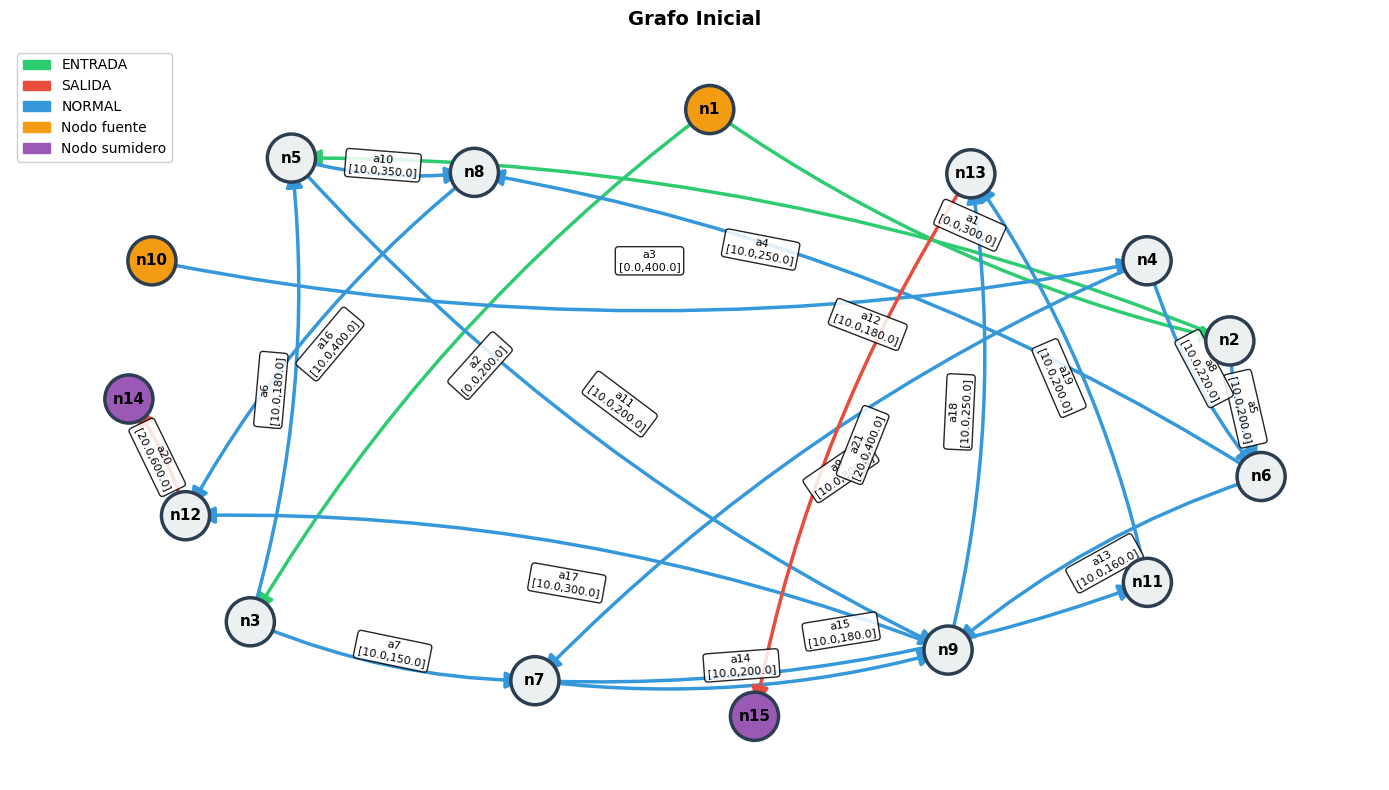

In [104]:
# Visualizar grafo inicial (sin flujo)
graph.draw(title="Grafo Inicial")

---
## 4. Algoritmo Genético
### 4.1 Parámetros configurables

In [105]:
# ===== PARÁMETROS DEL AG =====
N_INDIVIDUALS   = 50     # tamaño de la población
N_GENERATIONS   = 100    # número de generaciones
MUTATION_RATE   = 0.15   # probabilidad de mutar un gen
ELITISM_N       = 2      # cuántos mejores individuos pasan directamente
TOURNAMENT_K    = 3      # participantes en cada torneo de selección
TARGET_EFFICIENCY = 0.90 # detener si alcanzamos este % del flujo máximo teórico

### 4.2 Funciones del AG

In [106]:
# ---- Inicialización ----

def init_population(graph, n):
    """Crea n individuos aleatorios y evalúa su fitness."""
    pop = [Individual.random(graph) for _ in range(n)]
    for ind in pop:
        ind.evaluate(graph)
    return pop


# ---- Selección por torneo ----

def tournament_selection(population, k=3):
    """
    Elige k individuos al azar y devuelve el de mayor fitness.
    Evita que solo los mejores siempre ganen (mantiene diversidad).
    """
    candidates = random.sample(population, k)
    return max(candidates, key=lambda ind: ind.fitness)


# ---- Cruzamiento (crossover uniforme por nodo) ----

def crossover(parent1: Individual, parent2: Individual):
    """
    Para cada nodo, el hijo hereda los porcentajes de uno u otro padre
    con probabilidad 50/50. Esto produce dos hijos distintos.
    """
    child1_chromo = {}
    child2_chromo = {}
    all_nodes = set(parent1.chromosome) | set(parent2.chromosome)

    for nid in all_nodes:
        p1_genes = parent1.chromosome.get(nid, {})
        p2_genes = parent2.chromosome.get(nid, {})
        if random.random() < 0.5:
            child1_chromo[nid] = copy.deepcopy(p1_genes)
            child2_chromo[nid] = copy.deepcopy(p2_genes)
        else:
            child1_chromo[nid] = copy.deepcopy(p2_genes)
            child2_chromo[nid] = copy.deepcopy(p1_genes)

    return Individual(child1_chromo), Individual(child2_chromo)


# ---- Mutación ----

def mutate(individual: Individual, mutation_rate=0.15):
    """
    Con probabilidad mutation_rate, perturba los porcentajes de un nodo
    sumando ruido gaussiano y volviendo a normalizar.
    """
    for nid, pcts in individual.chromosome.items():
        if random.random() < mutation_rate:
            edges = list(pcts.keys())
            new_vals = {e: max(0.001, pcts[e] + random.gauss(0, 0.1)) for e in edges}
            total = sum(new_vals.values())
            individual.chromosome[nid] = {e: v / total for e, v in new_vals.items()}
    return individual


# ---- Nueva generación con elitismo ----

def next_generation(population, graph, mutation_rate, elitism_n, tournament_k):
    """
    Construye la siguiente generación:
    1. Los `elitism_n` mejores pasan sin cambios.
    2. El resto se genera con selección + crossover + mutación.
    """
    population.sort(key=lambda i: i.fitness, reverse=True)
    new_pop = population[:elitism_n]  # élite

    while len(new_pop) < len(population):
        p1 = tournament_selection(population, tournament_k)
        p2 = tournament_selection(population, tournament_k)
        c1, c2 = crossover(p1, p2)
        mutate(c1, mutation_rate)
        mutate(c2, mutation_rate)
        c1.evaluate(graph)
        c2.evaluate(graph)
        new_pop.extend([c1, c2])

    return new_pop[:len(population)]

### 4.3 Ejecución del AG

In [107]:
# Flujo máximo teórico = suma de flujos ENTRADA
max_possible = sum(e.flow for e in graph.edges.values() if e.edge_type == 'ENTRADA')
print(f"Flujo máximo de entrada: {max_possible}")

# Inicializar
population = init_population(graph, N_INDIVIDUALS)

history_best = []
history_avg  = []

print(f"\nIniciando AG: {N_INDIVIDUALS} individuos, {N_GENERATIONS} generaciones")
print("-" * 50)

for gen in range(N_GENERATIONS):
    best = max(population, key=lambda i: i.fitness)
    avg  = np.mean([i.fitness for i in population])
    history_best.append(best.fitness)
    history_avg.append(avg)

    efficiency = best.fitness / max_possible if max_possible > 0 else 0

    if gen % 10 == 0 or gen == N_GENERATIONS - 1:
        print(f"Gen {gen:4d} | Mejor={best.fitness:.1f} | Prom={avg:.1f} | Efic={efficiency:.1%}")

    if efficiency >= TARGET_EFFICIENCY:
        print(f"\n✓ Eficiencia objetivo {TARGET_EFFICIENCY:.0%} alcanzada en generación {gen}")
        break

    population = next_generation(population, graph, MUTATION_RATE, ELITISM_N, TOURNAMENT_K)

best_individual = max(population, key=lambda i: i.fitness)
print(f"\nMejor solución final: flujo={best_individual.fitness:.2f}")



Flujo máximo de entrada: 900.0

Iniciando AG: 50 individuos, 100 generaciones
--------------------------------------------------
Gen    0 | Mejor=900.0 | Prom=900.0 | Efic=100.0%

✓ Eficiencia objetivo 90% alcanzada en generación 0

Mejor solución final: flujo=900.00


---
## 5. Resultados
### 5.1 Curva de evolución

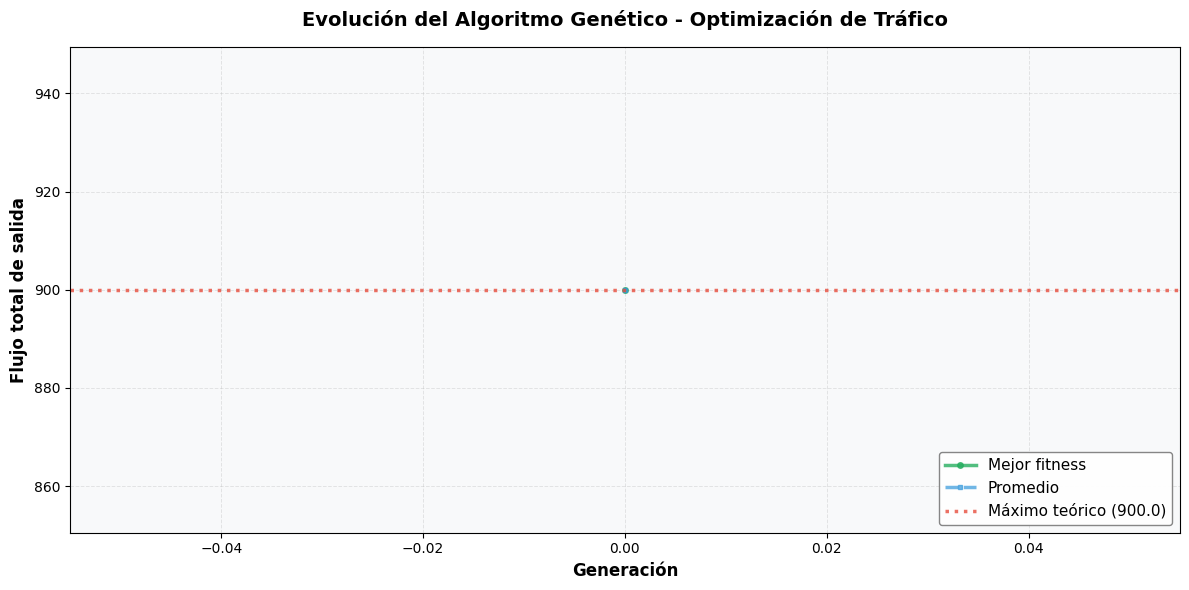

In [108]:
fig, ax = plt.subplots(figsize=(12, 6))

# Gráficas principales
ax.plot(history_best, label='Mejor fitness', color='#27ae60', linewidth=2.5, marker='o', markersize=4, alpha=0.8)
ax.plot(history_avg,  label='Promedio',     color='#3498db', linewidth=2.5, linestyle='--', marker='s', markersize=3.5, alpha=0.7)
ax.axhline(max_possible, color='#e74c3c', linestyle=':', linewidth=2.5, label=f'Máximo teórico ({max_possible})', alpha=0.8)

# Estilos mejorados
ax.set_xlabel('Generación', fontsize=12, fontweight='bold')
ax.set_ylabel('Flujo total de salida', fontsize=12, fontweight='bold')
ax.set_title('Evolución del Algoritmo Genético - Optimización de Tráfico', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, edgecolor='gray')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

# Agregar área sombreada entre mejor y promedio
ax.fill_between(range(len(history_best)), history_best, history_avg, alpha=0.15, color='#3498db')

plt.tight_layout()
plt.show()

### 5.2 Porcentajes óptimos por nodo (configuración de semáforos)

In [109]:
print("=" * 55)
print(" CONFIGURACIÓN ÓPTIMA DE SEMÁFOROS ")
print("=" * 55)
for nid, pcts in Individual.random(graph).chromosome.items():
    print(f"\nNodo {nid}:")
    for edge_name, pct in pcts.items():
        print(f"   -> {edge_name}: {pct*100:.1f}%")

 CONFIGURACIÓN ÓPTIMA DE SEMÁFOROS 

Nodo n1:
   -> a1: 41.2%
   -> a2: 58.8%

Nodo n2:
   -> a4: 1.1%
   -> a5: 98.9%

Nodo n3:
   -> a6: 24.1%
   -> a7: 75.9%

Nodo n4:
   -> a8: 86.2%
   -> a9: 13.8%

Nodo n5:
   -> a10: 42.3%
   -> a11: 57.7%

Nodo n6:
   -> a12: 51.5%
   -> a13: 48.5%

Nodo n7:
   -> a14: 71.1%
   -> a15: 28.9%

Nodo n9:
   -> a17: 43.5%
   -> a18: 56.5%


### 5.3 Flujos por arista con la solución óptima

In [110]:
optimal_flow = graph.simulate_flow(best_individual.chromosome)

print(f"{'Arista':<8} {'Tipo':<10} {'Flujo':>8} {'Cap.Máx':>8} {'Uso':>7}")
print("-" * 45)
for ename, e in graph.edges.items():
    f = optimal_flow[ename]
    uso = f / e.cap_max * 100 if e.cap_max > 0 else 0
    tipo = e.edge_type or 'interna'
    print(f"{ename:<8} {tipo:<10} {f:>8.1f} {e.cap_max:>8} {uso:>6.1f}%")

Arista   Tipo          Flujo  Cap.Máx     Uso
---------------------------------------------
a1       ENTRADA       300.0    300.0  100.0%
a2       ENTRADA       200.0    200.0  100.0%
a3       ENTRADA       400.0    400.0  100.0%
a4       interna       125.6    250.0   50.2%
a5       interna       174.4    200.0   87.2%
a6       interna        21.3    180.0   11.8%
a7       interna       178.7    150.0  119.2%
a8       interna       121.4    220.0   55.2%
a9       interna       278.6    300.0   92.9%
a10      interna        27.6    350.0    7.9%
a11      interna       119.3    200.0   59.7%
a12      interna       182.0    180.0  101.1%
a13      interna       113.8    160.0   71.1%
a14      interna        28.0    200.0   14.0%
a15      interna       429.4    180.0  238.5%
a16      interna       209.6    400.0   52.4%
a17      interna       126.6    300.0   42.2%
a18      interna       134.5    250.0   53.8%
a19      interna       429.4    200.0  214.7%
a20      SALIDA        336.2    60

### 5.4 Visualización del grafo con flujo óptimo

<Axes: title={'center': 'Red con Flujo Óptimo (AG) — Fitness: 900.0'}>

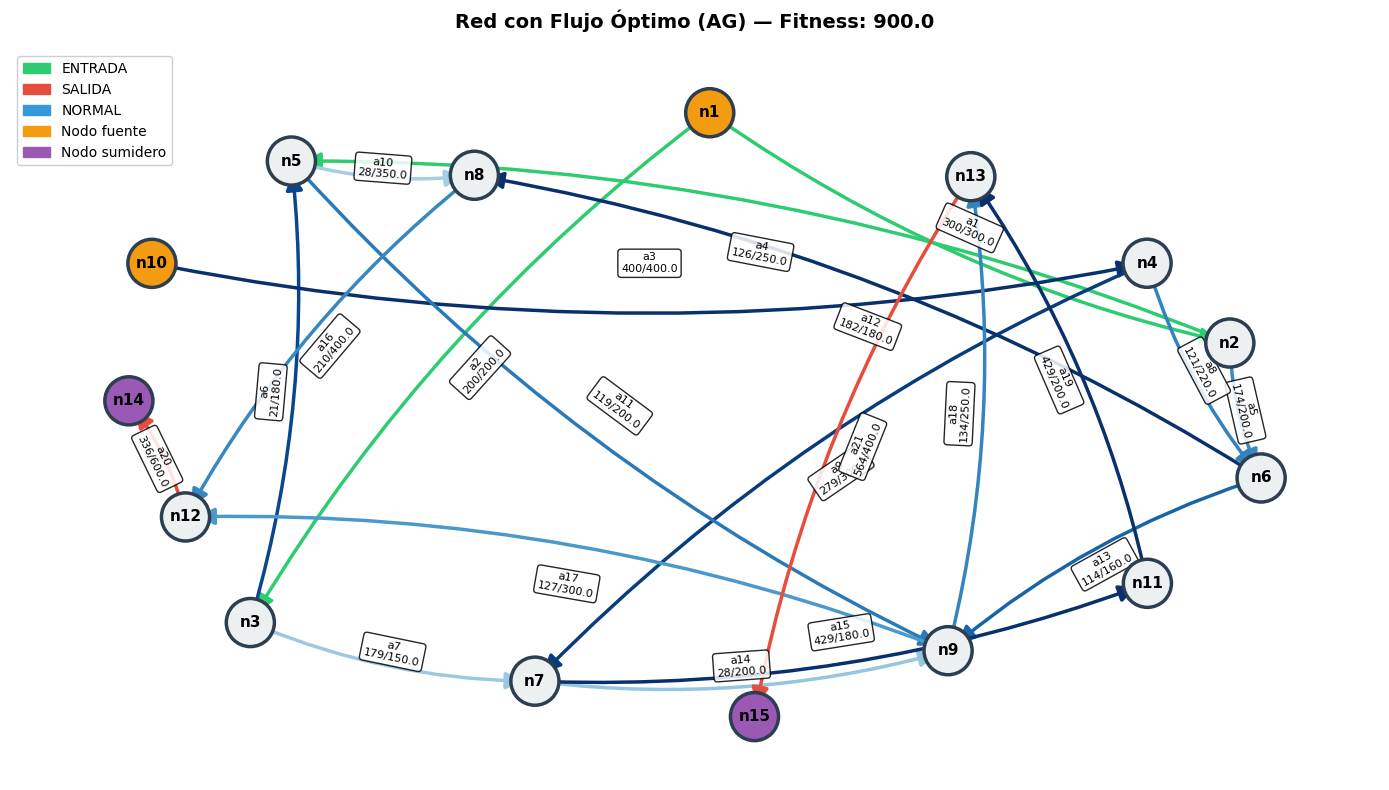

In [111]:
graph.draw(
    title=f"Red con Flujo Óptimo (AG) — Fitness: {best_individual.fitness:.1f}",
    flow_on_edge=optimal_flow
)